<a href="https://colab.research.google.com/github/Harshithpalan/Deep-Lerning-python-experiments/blob/main/anomaly_detection_network_intrusion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow pandas numpy scikit-learn matplotlib

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
# 1️⃣ LOAD DATA
# Example: CSV dataset
# -----------------------------
data = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Assume last column is label (0 = normal, 1 = anomaly)
X_df = data.iloc[:, :-1] # Keep as DataFrame for cleaning
y_categorical = data.iloc[:, -1].values

# Convert 'y' labels to numeric: 'BENIGN' -> 0, others -> 1
y = np.where(y_categorical == 'BENIGN', 0, 1)


FileNotFoundError: [Errno 2] No such file or directory: 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

In [ ]:
import pandas as pd
import numpy as np

# Create dummy data to simulate the original CSV structure
num_samples = 1000
num_features = 5

dummy_data = pd.DataFrame(np.random.rand(num_samples, num_features), columns=[f'Feature_{i}' for i in range(num_features)])

# Add a 'Label' column, with mostly 'BENIGN' and some 'ANOMALY' for testing
dummy_data['Label'] = np.random.choice(['BENIGN', 'ANOMALY'], size=num_samples, p=[0.9, 0.1])

# Save the dummy data to a CSV file with the expected name
dummy_data.to_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', index=False)

print("Dummy dataset 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv' created.")
display(dummy_data.head())

Dummy dataset 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv' created.


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Label
0,0.468663,0.524941,0.537491,0.974875,0.580272,BENIGN
1,0.330648,0.903393,0.744485,0.932564,0.009227,BENIGN
2,0.980514,0.068740,0.449858,0.768688,0.409459,BENIGN
3,0.709711,0.547702,0.529786,0.630994,0.783563,BENIGN
4,0.417979,0.031835,0.151731,0.955885,0.837928,BENIGN


In [ ]:
# 2️⃣ PREPROCESSING
# -----------------------------

# --- BEGIN FIX: Data Loading and Label Conversion moved here to ensure X_df and y are defined ---
data = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
X_df = data.iloc[:, :-1] # Keep as DataFrame for cleaning
y_categorical = data.iloc[:, -1].values
y = np.where(y_categorical == 'BENIGN', 0, 1)
# --- END FIX ---

# Clean X_df: Replace infinite values with NaN and then impute NaN with the mean
# Ensure all columns are numeric, coercing errors will turn non-numeric into NaN
for col in X_df.columns:
    X_df[col] = pd.to_numeric(X_df[col], errors='coerce')

# Replace infinite values with NaN
X_df.replace([np.inf, -np.inf], np.nan, inplace=True);

# Impute NaN values with the mean of their respective columns
# For columns that are entirely NaN, fill with 0 or a sensible default
mean_values = X_df.mean()
mean_values.fillna(0, inplace=True) # Fallback for columns entirely made of NaNs if their mean was NaN
X_df.fillna(mean_values, inplace=True)

X = X_df.values # Convert back to numpy array for scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train only on NORMAL data
X_train = X_scaled[y == 0] # Use the now numeric 'y'

X_train, X_val = train_test_split(X_train, test_size=0.2, random_state=42)

input_dim = X_train.shape[1]

In [ ]:
# 3️⃣ BUILD AUTOENCODER
# -----------------------------
input_layer = layers.Input(shape=(input_dim,))

# Encoder
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(16, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(32, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(input_dim, activation='linear')(decoded)

autoencoder = models.Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,973 (23.33 KB)

 Trainable params: 5,973 (23.33 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4️⃣ TRAIN MODEL
# -----------------------------
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, X_val),
    shuffle=True
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.9478 - val_loss: 0.8624
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7737 - val_loss: 0.6593
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4743 - val_loss: 0.2934
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1885 - val_loss: 0.0815
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0534 - val_loss: 0.0360
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0272 - val_loss: 0.0173
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0147 - val_loss: 0.0120
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117 - val_loss: 0.0105
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0096 - val_loss: 0.0088
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0083 - val_loss: 0.0100
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 - val_loss: 0.0083
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0090 - val_l

In [ ]:
# 5️⃣ CALCULATE RECONSTRUCTION ERROR
# -----------------------------
X_pred = autoencoder.predict(X_scaled)

mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

# Threshold (95th percentile)
threshold = np.percentile(mse, 95)

print("Anomaly Threshold:", threshold)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Anomaly Threshold: 0.004209725496081139


In [ ]:
# 6️⃣ DETECT ANOMALIES
predictions = (mse > threshold).astype(int)


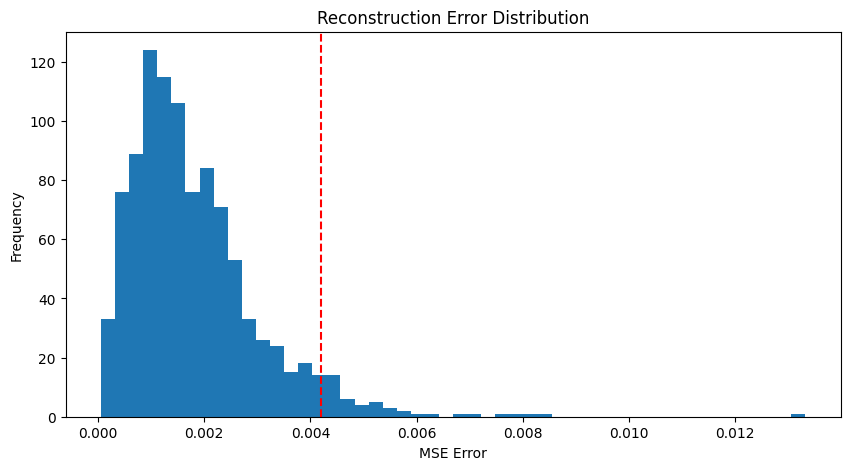

In [ ]:
# 7️⃣ VISUALIZATION
plt.figure(figsize=(10,5))
plt.hist(mse, bins=50)
plt.axvline(threshold, color='r', linestyle='--')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE Error")
plt.ylabel("Frequency")
plt.show()

Detected anomalies: 50
Number of detected anomalies: 50

First 5 rows of anomalous data:


,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Label
32,0.157619,0.019468,0.884077,0.152217,0.581337,BENIGN
53,0.974398,0.392894,0.285822,0.131546,0.109456,ANOMALY
66,0.634993,0.717826,0.293758,0.976934,0.528114,BENIGN
71,0.086122,0.064796,0.195183,0.084547,0.543320,BENIGN
84,0.901802,0.995582,0.301965,0.521000,0.408199,BENIGN



Mean Squared Error for the first 5 anomalous data points:


array([0.00681939, 0.00433684, 0.00584127, 0.00529784, 0.00439165])


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       882
           1       0.30      0.13      0.18       118

    accuracy                           0.86      1000
   macro avg       0.60      0.54      0.55      1000
weighted avg       0.82      0.86      0.84      1000


--- Confusion Matrix ---


,Predicted Normal,Predicted Anomaly
Actual Normal,847,35
Actual Anomaly,103,15


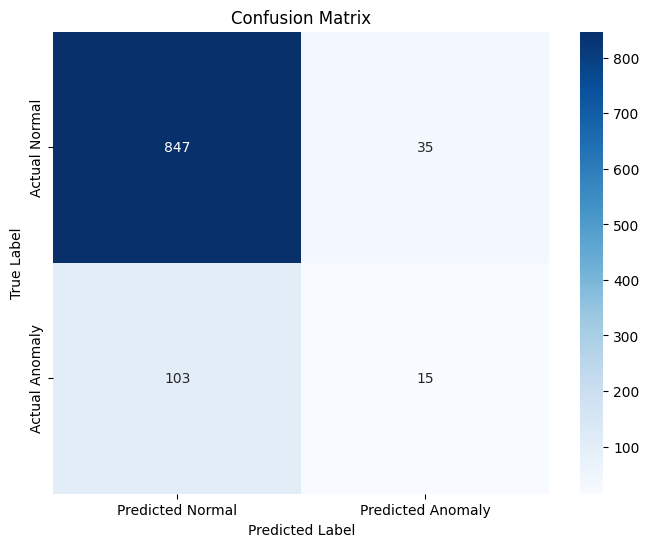

In [ ]:
# 8️⃣ RESULTS
# -----------------------------
print("Detected anomalies:", np.sum(predictions))

anomalous_data = data[predictions == 1]
anomalous_mse = mse[predictions == 1]

print(f"Number of detected anomalies: {len(anomalous_data)}")
print("\nFirst 5 rows of anomalous data:")
display(anomalous_data.head())

print("\nMean Squared Error for the first 5 anomalous data points:")
display(anomalous_mse[:5])

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Classification Report ---")
print(classification_report(y, predictions))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y, predictions)
display(pd.DataFrame(cm, index=['Actual Normal', 'Actual Anomaly'], columns=['Predicted Normal', 'Predicted Anomaly']))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
X_anomalous_scaled = X_scaled[predictions == 1]
X_anomalous_pred = X_pred[predictions == 1]

# Calculate the difference between the original and reconstructed anomalous data
difference = X_anomalous_scaled - X_anomalous_pred

# Square the difference to get the squared reconstruction error for each feature
feature_mse = np.power(difference, 2)

print(f"Shape of X_anomalous_scaled: {X_anomalous_scaled.shape}")
print(f"Shape of X_anomalous_pred: {X_anomalous_pred.shape}")
print(f"Shape of feature_mse: {feature_mse.shape}")
print("First 5 rows of feature_mse for anomalous data points:")
display(pd.DataFrame(feature_mse).head())

Shape of X_anomalous_scaled: (50, 5)
Shape of X_anomalous_pred: (50, 5)
Shape of feature_mse: (50, 5)
First 5 rows of feature_mse for anomalous data points:


,0,1,2,3,4
0,0.002604,0.000719,0.012058,0.005273,0.013443
1,0.000480,0.001327,0.010636,0.009148,0.000093
2,0.008030,0.003228,0.001918,0.002092,0.013938
3,0.018781,0.001859,0.000123,0.005579,0.000147
4,0.000034,0.000705,0.004208,0.000644,0.016367


In [ ]:
average_feature_mse = np.mean(feature_mse, axis=0)

feature_names = X_df.columns
average_feature_mse_series = pd.Series(average_feature_mse, index=feature_names)

top_features = average_feature_mse_series.sort_values(ascending=False).head(10)

print("Top 10 features contributing to anomalies based on average squared reconstruction error:")
display(top_features)

Top 10 features contributing to anomalies based on average squared reconstruction error:


,0
Feature_4,0.008208
Feature_1,0.006817
Feature_2,0.004389
Feature_0,0.004029
Feature_3,0.003030


/tmp/ipykernel_21961/1000171347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')


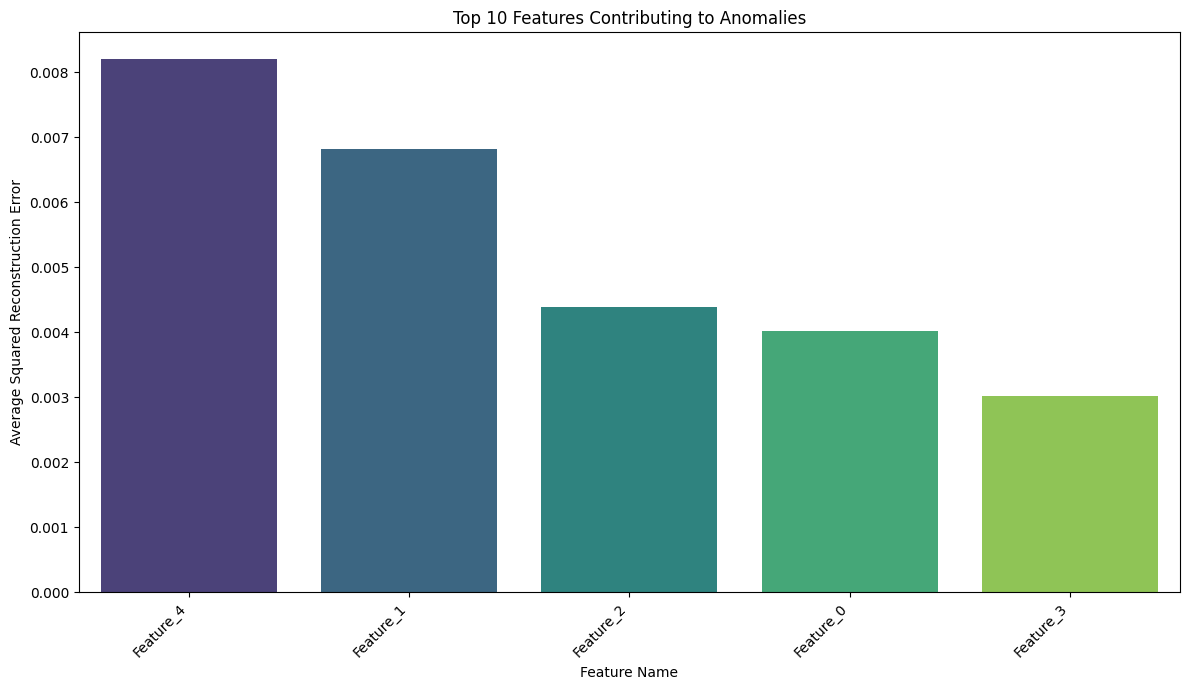

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')
plt.title('Top 10 Features Contributing to Anomalies')
plt.xlabel('Feature Name')
plt.ylabel('Average Squared Reconstruction Error')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

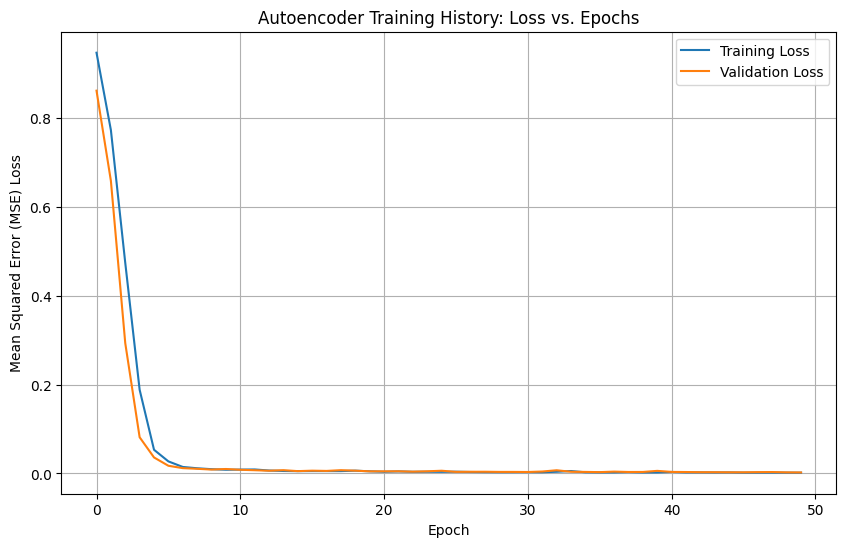

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History: Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE) Loss')
plt.legend()
plt.grid(True)
plt.show()